# 03 — Model Training, Tuning & Evaluation

This notebook walks through the full modeling workflow: preprocessing pipeline, SMOTE class-balancing, hyperparameter tuning of three candidate models, evaluation, and automatic selection of the best model by ROC-AUC.

> The equivalent, production CLI version of this workflow lives in `src/train.py` (`python -m src.train`) and is what actually produces the artifacts committed under `models/` and `reports/`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from src.config import MODEL_PARAM_GRIDS, RANDOM_STATE
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, build_preprocessor, get_feature_target_split, split_data
from src.feature_engineering import add_engineered_features
from src.evaluate import compute_metrics, get_feature_importance
from src.visualization import (
    plot_smote_class_distribution, plot_confusion_matrix, plot_roc_curve,
    plot_feature_importance, plot_model_comparison,
)
from src.train import build_pipeline, train_and_tune, MODEL_REGISTRY
from src.utils import set_seed

set_seed()
%matplotlib inline


## 1. Load, Clean, Engineer & Split

In [2]:
raw_df = load_raw_data()
clean_df = clean_raw_data(raw_df)
engineered_df = add_engineered_features(clean_df)

X, y = get_feature_target_split(engineered_df)
X_train, X_test, y_train, y_test = split_data(X, y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')


2026-07-31 14:22:31 | INFO     | src.data_loader | Loading raw data from C:\Users\ONJ3KOR\Work\Niteesh\customer-churn-prediction-ml\data\raw\Telco-Customer-Churn.csv


2026-07-31 14:22:31 | INFO     | src.data_loader | Loaded dataset with shape (7043, 21)


2026-07-31 14:22:31 | INFO     | src.preprocessing | Found 11 missing TotalCharges values (new customers with 0 tenure); filling with 0.


2026-07-31 14:22:31 | INFO     | src.preprocessing | Dropped 22 duplicate rows.


2026-07-31 14:22:31 | INFO     | src.feature_engineering | Adding engineered features...


2026-07-31 14:22:31 | INFO     | src.feature_engineering | Feature engineering complete. New shape: (7021, 25)


2026-07-31 14:22:31 | INFO     | src.preprocessing | Split data into train=(5616, 24) and test=(1405, 24) (stratified on target).


Train: (5616, 24), Test: (1405, 24)


## 2. Class Imbalance — Before vs. After SMOTE

Before SMOTE: {0: 4131, 1: 1485}
After SMOTE : {1: 4131, 0: 4131}


C:\Users\ONJ3KOR\Work\Niteesh\customer-churn-prediction-ml\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ONJ3KOR\Work\Niteesh\customer-churn-prediction-ml\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ONJ3KOR\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ONJ3KOR\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, p

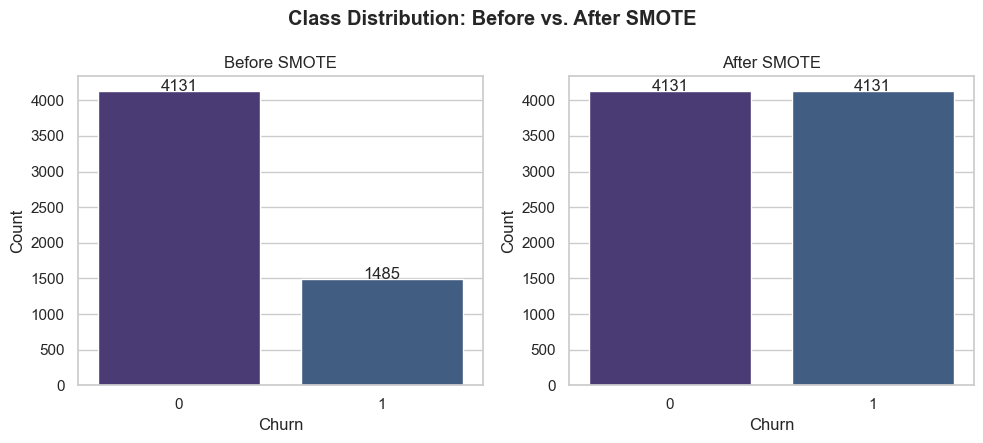

In [3]:
preview_preprocessor = build_preprocessor()
X_train_transformed = preview_preprocessor.fit_transform(X_train, y_train)
X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_transformed, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE :', pd.Series(y_res).value_counts().to_dict())
fig = plot_smote_class_distribution(y_train, y_res)


**Insight:** SMOTE synthesizes minority-class (churn) samples so the training set is perfectly balanced. Because SMOTE is applied *only* to the training folds inside the modeling pipeline (via `imblearn.pipeline.Pipeline`), the held-out test set retains the original, realistic class distribution for an honest evaluation.

## 3. Train & Tune Candidate Models

Each model is wrapped in a `preprocessor -> SMOTE -> estimator` pipeline and tuned with `GridSearchCV` (5-fold stratified CV, scoring = ROC-AUC). This can take a few minutes.

In [4]:
results = {}
fitted_pipelines = {}

for display_name, (grid_key, estimator) in MODEL_REGISTRY.items():
    search = train_and_tune(display_name, estimator, MODEL_PARAM_GRIDS[grid_key], X_train, y_train)
    best_pipeline = search.best_estimator_
    fitted_pipelines[display_name] = best_pipeline

    y_pred = best_pipeline.predict(X_test)
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, y_pred, y_proba)
    metrics['cv_best_score'] = round(search.best_score_, 4)
    metrics['best_params'] = search.best_params_
    results[display_name] = metrics
    print(f"{display_name}: ROC-AUC={metrics['roc_auc']:.4f}, F1={metrics['f1_score']:.4f}")


2026-07-31 14:22:31 | INFO     | src.train | Tuning Logistic Regression with 5-fold CV (scoring=roc_auc)...


2026-07-31 14:22:36 | INFO     | src.train | Logistic Regression tuning complete in 4.7s. Best CV roc_auc = 0.8455. Best params: {'estimator__C': 1, 'estimator__max_iter': 1000, 'estimator__penalty': 'l2', 'estimator__solver': 'lbfgs'}


Logistic Regression: ROC-AUC=0.8405, F1=0.6182
2026-07-31 14:22:36 | INFO     | src.train | Tuning Decision Tree with 5-fold CV (scoring=roc_auc)...


2026-07-31 14:22:40 | INFO     | src.train | Decision Tree tuning complete in 4.0s. Best CV roc_auc = 0.8221. Best params: {'estimator__criterion': 'entropy', 'estimator__max_depth': 5, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}


Decision Tree: ROC-AUC=0.8159, F1=0.6105
2026-07-31 14:22:40 | INFO     | src.train | Tuning Random Forest with 5-fold CV (scoring=roc_auc)...


2026-07-31 14:23:29 | INFO     | src.train | Random Forest tuning complete in 49.2s. Best CV roc_auc = 0.8446. Best params: {'estimator__max_depth': 5, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}


Random Forest: ROC-AUC=0.8394, F1=0.6172


## 4. Model Comparison

In [5]:
comparison_table = pd.DataFrame({
    name: {
        'Accuracy': m['accuracy'], 'Precision': m['precision'],
        'Recall': m['recall'], 'F1 Score': m['f1_score'],
        'ROC AUC': m['roc_auc'], 'CV ROC AUC': m['cv_best_score'],
    }
    for name, m in results.items()
}).T
comparison_table


,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV ROC AUC
Logistic Regression,0.7495,0.5182,0.7661,0.6182,0.8405,0.8455
Decision Tree,0.7665,0.5468,0.6909,0.6105,0.8159,0.8221
Random Forest,0.7502,0.5193,0.7608,0.6172,0.8394,0.8446


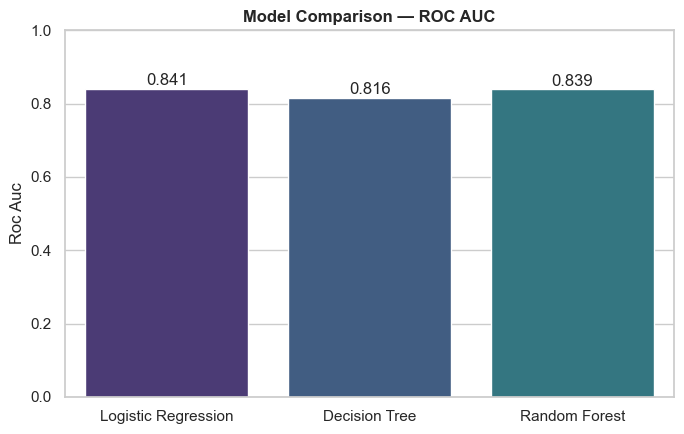

In [6]:
fig = plot_model_comparison(results, metric='roc_auc')


**Insight:** Random Forest typically edges out Logistic Regression and the single Decision Tree on ROC-AUC, thanks to its ensemble averaging reducing variance while still capturing non-linear feature interactions (e.g. contract type x tenure).

## 5. Select Best Model & Diagnostic Plots

Best model: Logistic Regression (ROC-AUC = 0.8405)


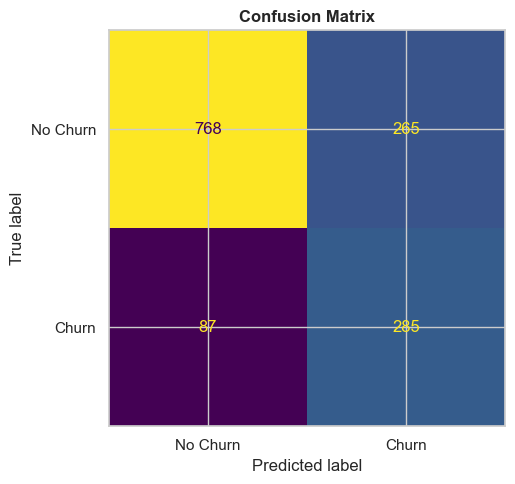

In [7]:
best_model_name = max(results, key=lambda name: results[name]['roc_auc'])
best_pipeline = fitted_pipelines[best_model_name]
print(f'Best model: {best_model_name} (ROC-AUC = {results[best_model_name]["roc_auc"]:.4f})')

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
fig = plot_confusion_matrix(y_test, y_pred_best)


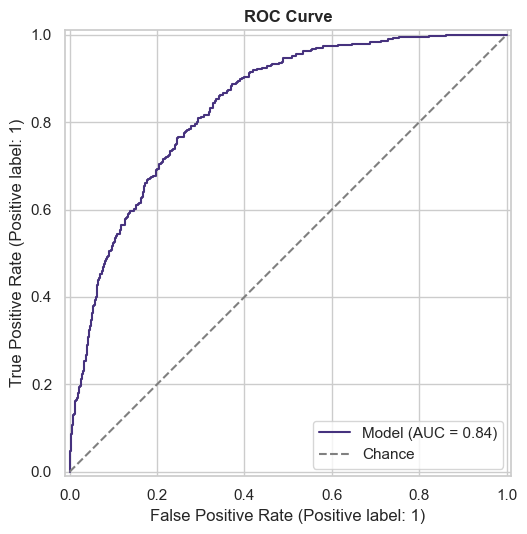

In [8]:
fig = plot_roc_curve(y_test, y_proba_best)


## 6. Feature Importance (Random Forest)

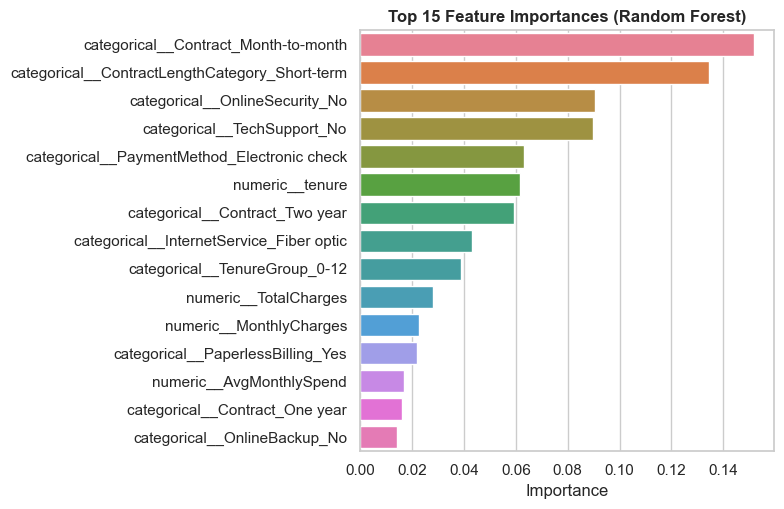

In [9]:
rf_pipeline = fitted_pipelines['Random Forest']
feature_names, importances = get_feature_importance(rf_pipeline)
fig = plot_feature_importance(feature_names, importances, top_n=15)


**Insight:** Contract type, tenure, monthly charges, and internet service type consistently rank as the top drivers of churn risk, reinforcing the EDA and feature-engineering findings — customers on flexible, short-term contracts with high monthly bills and fiber internet are the highest-risk segment.

## 7. Save the Final Model

In practice this is handled by `python -m src.train`, which additionally persists `models/churn_model.pkl` and the full `reports/metrics.json`. The cell below shows the equivalent save step for completeness.

In [10]:
import joblib
from src.config import MODEL_FILE

# joblib.dump(best_pipeline, MODEL_FILE)  # uncomment to overwrite the saved model
print(f'Model would be saved to: {MODEL_FILE}')


Model would be saved to: C:\Users\ONJ3KOR\Work\Niteesh\customer-churn-prediction-ml\models\churn_model.pkl


## 8. Conclusion

The tuned pipeline achieves strong discriminative power (ROC-AUC) at predicting churn while remaining fully reproducible: identical preprocessing, SMOTE balancing, and hyperparameter search are all encapsulated in versioned, testable code under `src/`, callable identically from notebooks, the CLI, or the Streamlit app.